# Kalibrering og statistisk inferens

```{admonition} Læringsutbytte
Etter å ha arbeidet med dette temaet, skal du kunne:

1. bruke lineær regresjon til å lage en kalibreringsmodell
2. tolke stigningstall, konstantledd og $R^2$ i en kjemisk sammenheng
3. bruke modellen til å bestemme en ukjent konsentrasjon
4. forklare nullhypotese, t-statistikk, frihetsgrader, p-verdi og signifikansnivå
5. velge mellom ettutvalgs t-test, Welchs t-test for uavhengige utvalg og paret t-test
6. rapportere forskjell, konfidensintervall, t-statistikk, frihetsgrader og p-verdi
7. bruke Grubbs' test som statistisk flagging av én mulig utligger – ikke som en automatisk regel for sletting
```

I forrige kapittel brukte vi statistikk til å beskrive måleserier og usikkerheten i et gjennomsnitt. Nå skal vi bruke de samme ideene til tre vanlige oppgaver i kjemi:

1. lage en kalibreringsmodell og bruke den til å bestemme en ukjent konsentrasjon
2. sammenlikne et måleresultat med en referanseverdi, eller sammenlikne grupper og analysemetoder
3. undersøke om én på forhånd mistenkelig måling bør flagges for nærmere faglig vurdering

Målet er ikke å samle flest mulig statistiske tester. Målet er å velge en metode som svarer på det kjemiske spørsmålet og passer til forsøksdesignet.


## Del 1: Fra kalibreringsstandarder til ukjent konsentrasjon

### Den kjemiske modellen

I UV–Vis-spektroskopi beskriver Beer–Lamberts lov sammenhengen mellom absorbans og konsentrasjon:

$$
A=\varepsilon lc
$$

Her er $A$ absorbansen, $\varepsilon$ den molare absorptiviteten, $l$ lysveien og $c$ konsentrasjonen. Når lysveien og de kjemiske betingelsene er konstante, forventer vi at absorbansen øker omtrent lineært med konsentrasjonen innenfor et passende område.

Virkelige målinger ligger ikke på en helt perfekt linje. Derfor tilpasser vi en rett linje til kalibreringsdataene:

$$
A=ac+b
$$

Her er $a$ stigningstallet og $b$ konstantleddet.

```{admonition} Kalibreringsmodell
En kalibreringsmodell beskriver sammenhengen mellom et målt signal og kjente verdier av størrelsen vi vil bestemme. Modellen brukes deretter til å anslå verdien i en ukjent prøve **innenfor det undersøkte og validerte kalibreringsområdet**.
```

Den rette linja er en modell. Den garanterer ikke at lineariteten fortsetter utenfor området vi har undersøkt.


### Se på dataene først

Vi begynner med blankprøvene og kalibreringsstandardene. Når alle replikatene vises, kan vi undersøke både trenden og spredningen i målingene.


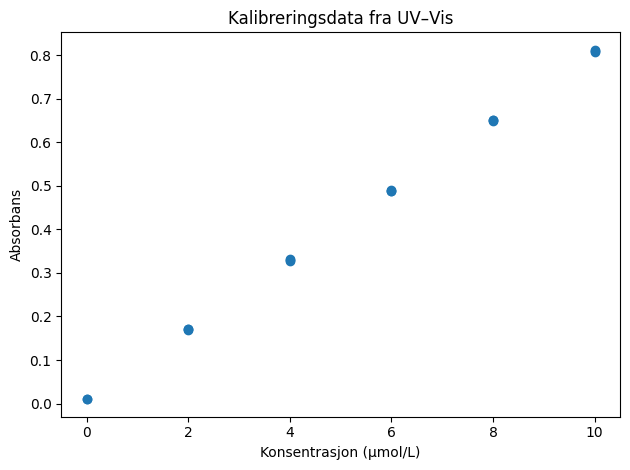

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data/uvvis_calibration.csv")
standards = data[data["sample_type"].isin(["blank", "standard"])]

plt.scatter(standards["concentration_uM"], standards["absorbance"])
plt.xlabel("Konsentrasjon (µmol/L)")
plt.ylabel("Absorbans")
plt.title("Kalibreringsdata fra UV–Vis")
plt.tight_layout()
plt.show()


Punktene ser ut til å følge en omtrent rett linje. Det gir oss både en kjemisk og en visuell grunn til å prøve en lineær modell.

### Lineær regresjon

```{admonition} Lineær regresjon
Lineær regresjon estimerer den rette linja som best beskriver sammenhengen mellom en responsvariabel $y$ og en forklaringsvariabel $x$, gitt forutsetningene for modellen.
```

Vi bruker `linregress` fra SciPy:


In [2]:
import numpy as np
from scipy import stats

concentrations = standards["concentration_uM"]
absorbances = standards["absorbance"]

regression = stats.linregress(concentrations, absorbances)
slope = regression.slope
intercept = regression.intercept
r_squared = regression.rvalue**2

print(f"Stigningstall: {slope:.5f} L/µmol")
print(f"Konstantledd:  {intercept:.5f}")
print(f"R²:            {r_squared:.6f}")


Stigningstall: 0.07989 L/µmol
Konstantledd:  0.01037
R²:            0.999964


Resultatet inneholder flere størrelser, men ingen av dem bør rapporteres uten tolkning.

#### Stigningstallet

Stigningstallet forteller hvor mye den tilpassede absorbansen øker når konsentrasjonen øker med 1 µmol/L. Et brattere stigningstall betyr at signalet endres mer for en gitt konsentrasjonsendring. I denne sammenhengen sier vi at kalibreringen har større **følsomhet**.

Følsomhet er ikke det samme som presisjon. To metoder kan ha samme stigningstall, men ulik spredning mellom replikatene.

#### Konstantleddet

Konstantleddet er absorbansen modellen forventer ved konsentrasjon null. Det kan blant annet påvirkes av blankbidrag, instrumentets nullpunkt og tilfeldig målevariasjon.

Beer–Lamberts lov skrives ofte uten konstantledd, men vi bør ikke automatisk tvinge regresjonslinja gjennom origo. Det påfører modellen en ekstra antakelse som må begrunnes eksperimentelt.

#### $R^2$

```{admonition} Forklaringsgraden $R^2$
For denne enkle lineære regresjonen oppsummerer $R^2$ hvor mye av variasjonen i responsen som er knyttet til den tilpassede lineære sammenhengen. Verdier nær 1 betyr at punktene ligger nær en rett linje.
```

Et høyt $R^2$ er **ikke** et fullstendig kvalitetskriterium. Vi må også se på rådataene, variasjonen mellom replikatene, kalibreringsområdet og om modellen er kjemisk rimelig. Et datasett kan ha høyt $R^2$ selv om én standard er problematisk eller det høyeste konsentrasjonsområdet begynner å avvike systematisk fra Beer–Lamberts lov.


### Vis data og modell sammen

Vi beregner modellverdier gjennom kalibreringsområdet og tegner regresjonslinja sammen med råmålingene.


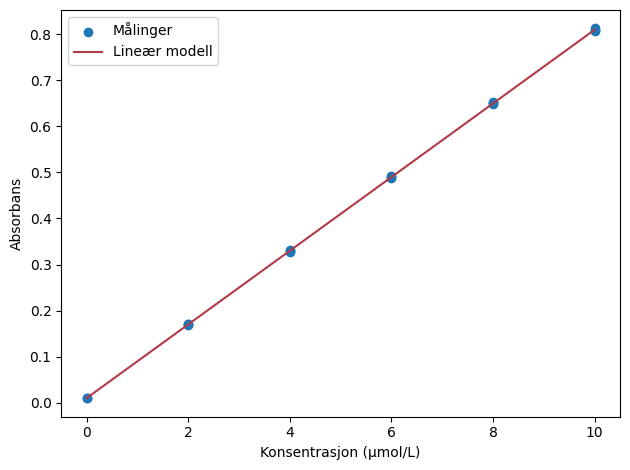

In [3]:
x_model = np.linspace(concentrations.min(), concentrations.max(), 100)
y_model = slope * x_model + intercept

plt.scatter(concentrations, absorbances, label="Målinger")
plt.plot(x_model, y_model, color="#b23a48", label="Lineær modell")
plt.xlabel("Konsentrasjon (µmol/L)")
plt.ylabel("Absorbans")
plt.legend()
plt.tight_layout()
plt.show()


Vi beholder råmålingene i figuren. Dersom vi bare viser ett gjennomsnitt for hver konsentrasjon, skjuler vi variasjonen mellom replikatene.

Du kan utforske kalibreringen i editoren nedenfor.

<iframe src="../../basthon/?from=examples/calibration_regression.py" width="100%" height="690" frameborder="0" title="Interaktiv Python-editor for UV–Vis-kalibrering" loading="lazy" allowfullscreen></iframe>


### Bestem den ukjente konsentrasjonen

For en ukjent prøve måler vi absorbansen og løser kalibreringslikningen med hensyn på konsentrasjonen:

$$
c=\frac{A-b}{a}
$$

Parentesene i Python-uttrykket er avgjørende: hele differansen $A-b$ skal deles på $a$.


In [4]:
unknown = data[data["sample_type"] == "unknown"]
unknown_mean_absorbance = unknown["absorbance"].mean()

unknown_concentration = (unknown_mean_absorbance - intercept) / slope

print(f"Middelabsorbans:       {unknown_mean_absorbance:.4f}")
print(f"Estimert konsentrasjon: {unknown_concentration:.3f} µmol/L")


Middelabsorbans:       0.6043
Estimert konsentrasjon: 7.435 µmol/L


Estimatet ligger innenfor kalibreringsområdet. Det er viktig: Ekstrapolasjon utenfor standardområdet forutsetter at den samme sammenhengen fortsetter i et område der den ikke er undersøkt.

Denne enkle beregningen gir et punktestimat. En fullstendig vurdering av analytisk usikkerhet må også ta hensyn til usikkerheten i selve kalibreringen, replikatene, standardene og relevante trinn i prøveprepareringen.

````{admonition} Underveisoppgave
:class: tip

1. Legg til 0,01 i alle absorbansverdiene. Hva skjer med stigningstallet og konstantleddet?
2. Endre bare den høyeste kalibreringsstandarden. Hva skjer med linja og $R^2$?
3. Anta at en ukjent prøve har absorbans 1,20, mens den høyeste standarden har absorbans omtrent 0,81. Hvorfor er det problematisk å sette 1,20 direkte inn i likningen, og hva bør du gjøre eksperimentelt?

```{admonition} Løsningsforslag
:class: tip, dropdown
Når alle absorbansene økes like mye, endres først og fremst konstantleddet. En endring i ett kalibreringspunkt kan påvirke både stigningstall og $R^2$. En absorbans på 1,20 krever ekstrapolasjon utenfor det undersøkte området. Vanligvis bør prøven fortynnes inn i det validerte området, eller kalibreringsområdet utvides og valideres med nye standarder.
```
````


## Del 2: Sammenlikne et resultat med en referanseverdi

Tenk deg at vi analyserer et sertifisert referansemateriale med konsentrasjon 5,00 mg/L og får disse resultatene:

```{code-block} text
5,12, 5,08, 5,15, 5,10, 5,13 mg/L
```

Gjennomsnittet er 5,116 mg/L. Er forskjellen fra 5,00 mg/L forenlig med tilfeldig målevariasjon, eller tyder den på systematisk avvik?

### Start med estimat og konfidensintervall

I forrige kapittel beregnet vi et 95 % konfidensintervall fra omtrent 5,082 til 5,150 mg/L. Referanseverdien 5,00 mg/L ligger utenfor intervallet. Gitt antakelsene bak intervallet forteller det allerede at referanseverdien er vanskelig å forene med måleserien.

Konfidensintervaller er ofte mer informative enn et binært testresultat fordi de viser både størrelsen på estimatet og presisjonen.


### Hypotesetesting med t-tester

En hypotesetest begynner med en presis påstand som brukes som sammenlikningsgrunnlag:

```{admonition} Nullhypotesen
**Nullhypotesen**, $H_0$, er en presis referansepåstand som vi bruker til å beregne hvor uvanlige dataene ville vært dersom påstanden og modellforutsetningene var riktige.
```

I dette eksemplet er

$$
H_0:\mu=5{,}00\ \mathrm{mg/L}
$$

og den tosidige alternative hypotesen er

$$
H_1:\mu\ne5{,}00\ \mathrm{mg/L}.
$$

Testen gir en **t-statistikk** og en **p-verdi**.

```{admonition} P-verdi
P-verdien er sannsynligheten for å få en t-statistikk som er minst like uforenlig med $H_0$ som den observerte, **dersom nullhypotesen og modellforutsetningene er riktige**.
```

P-verdien er ikke sannsynligheten for at nullhypotesen er sann. $1-p$ er heller ikke sannsynligheten for at vår foretrukne forklaring er riktig. En høy p-verdi beviser ikke at to størrelser er like; den kan også skyldes få eller upresise målinger.

Vi velger et signifikansnivå $\alpha$ før vi ser testresultatet, ofte 0,05. Dersom $p<\alpha$, forkaster vi $H_0$. Dersom $p\geq\alpha$, **forkaster vi ikke** $H_0$; vi godtar eller beviser den ikke. Ved gjentatte tester vil en prosedyre med $\alpha=0{,}05$ forkaste en sann nullhypotese i omtrent 5 % av tilfellene dersom alle forutsetningene er oppfylt.

Alle eksemplene nedenfor bruker tosidige tester. En ensidig test må bygge på en faglig begrunnet retningsbestemt hypotese som er formulert før dataene undersøkes.


### Ettutvalgs t-test

En ettutvalgs t-test sammenlikner gjennomsnittet $\bar{x}$ i én måleserie med en oppgitt referanseverdi $\mu_0$:

$$
t=\frac{\bar{x}-\mu_0}{s/\sqrt{n}}
$$

Nevneren $s/\sqrt{n}$ er standardfeilen til gjennomsnittet. Teststatistikken uttrykker dermed forskjellen i antall standardfeil. For ett utvalg er antall frihetsgrader

$$
df=n-1.
$$

Koden nedenfor viser både mellomregningene og resultatet fra `stats.ttest_1samp`.


In [5]:
measurements_mg_L = np.array([5.12, 5.08, 5.15, 5.10, 5.13])
reference_value = 5.00
alpha = 0.05

n = len(measurements_mg_L)
mean = np.mean(measurements_mg_L)
sample_sd = np.std(measurements_mg_L, ddof=1)
standard_error = sample_sd / np.sqrt(n)
mean_difference = mean - reference_value
df = n - 1

t_manual = mean_difference / standard_error
test = stats.ttest_1samp(measurements_mg_L, popmean=reference_value)

t_critical = stats.t.ppf(1 - alpha / 2, df=df)
ci_lower = mean - t_critical * standard_error
ci_upper = mean + t_critical * standard_error

print(f"n:                         {n}")
print(f"Gjennomsnitt:              {mean:.3f} mg/L")
print(f"Forskjell fra referansen:  {mean_difference:.3f} mg/L")
print(f"Standardfeil:              {standard_error:.4f} mg/L")
print(f"95 % KI for gjennomsnitt:  [{ci_lower:.3f}, {ci_upper:.3f}] mg/L")
print(f"t-statistikk:              {test.statistic:.3f}")
print(f"Frihetsgrader:             {df}")
print(f"p-verdi (tosidig):         {test.pvalue:.5f}")
print(f"Kontroll av t-beregningen: {t_manual:.3f}")


n:                         5
Gjennomsnitt:              5.116 mg/L
Forskjell fra referansen:  0.116 mg/L
Standardfeil:              0.0121 mg/L
95 % KI for gjennomsnitt:  [5.082, 5.150] mg/L
t-statistikk:              9.600
Frihetsgrader:             4
p-verdi (tosidig):         0.00066
Kontroll av t-beregningen: 9.600


P-verdien er mindre enn 0,05, og 95 % konfidensintervallet omfatter ikke referanseverdien. Dataene gir derfor grunnlag for å forkaste nullhypotesen om at middelverdien er 5,00 mg/L, gitt testens antakelser.

Resultatet må også vurderes kjemisk. Den estimerte forskjellen er 0,116 mg/L. Om dette er viktig, avhenger blant annet av formålet, kravene til metoden og usikkerheten i referanseverdien.

```{admonition} Forutsetninger for ettutvalgs t-test
- Observasjonene skal være uavhengige.
- Målingene skal representere den samme populasjonen eller måleprosessen.
- Fordelingen målingene trekkes fra, bør være omtrent normal. Dette er særlig viktig ved små utvalg.
- Sterke utliggere kan dominere både gjennomsnittet og standardavviket.
```

En kort rapportering kan for eksempel inneholde estimert forskjell med konfidensintervall, $t$, $df$ og $p$ – ikke bare «signifikant» eller «ikke signifikant».


## Del 3: Sammenlikne to uavhengige grupper

En uavhengig t-test brukes når observasjonene i de to gruppene kommer fra forskjellige, uavhengige utvalg. Det finnes ingen naturlig paring mellom én måling i gruppe A og én bestemt måling i gruppe B.

Tenk deg at vi undersøker to uavhengig produserte batcher. Nullhypotesen er

$$
H_0:\mu_B-\mu_A=0,
$$

mens den tosidige alternative hypotesen er $H_1:\mu_B-\mu_A\ne0$.

Vi bruker **Welchs t-test** ved å sette `equal_var=False`. Denne varianten krever ikke at populasjonene har samme varians og er derfor et godt standardvalg ved sammenlikning av uavhengige grupper.


In [6]:
batch_A = np.array([5.01, 5.08, 5.04, 4.99, 5.06, 5.03])
batch_B = np.array([5.18, 5.11, 5.16, 5.20, 5.14, 5.17])

n_A = len(batch_A)
n_B = len(batch_B)
mean_A = np.mean(batch_A)
mean_B = np.mean(batch_B)
variance_A = np.var(batch_A, ddof=1)
variance_B = np.var(batch_B, ddof=1)

difference = mean_B - mean_A
standard_error = np.sqrt(variance_A / n_A + variance_B / n_B)

# Welch–Satterthwaite-tilnærmingen gir frihetsgradene.
df_numerator = (variance_A / n_A + variance_B / n_B) ** 2
df_denominator = (
    (variance_A / n_A) ** 2 / (n_A - 1)
    + (variance_B / n_B) ** 2 / (n_B - 1)
)
df = df_numerator / df_denominator

test = stats.ttest_ind(batch_B, batch_A, equal_var=False)
t_critical = stats.t.ppf(1 - alpha / 2, df=df)
ci_lower = difference - t_critical * standard_error
ci_upper = difference + t_critical * standard_error

print(f"Gjennomsnitt A:          {mean_A:.3f} mg/L")
print(f"Gjennomsnitt B:          {mean_B:.3f} mg/L")
print(f"Forskjell B − A:         {difference:.3f} mg/L")
print(f"95 % KI for forskjellen: [{ci_lower:.3f}, {ci_upper:.3f}] mg/L")
print(f"t-statistikk:            {test.statistic:.3f}")
print(f"Frihetsgrader:           {df:.2f}")
print(f"p-verdi (tosidig):       {test.pvalue:.5f}")


Gjennomsnitt A:          5.035 mg/L
Gjennomsnitt B:          5.160 mg/L
Forskjell B − A:         0.125 mg/L
95 % KI for forskjellen: [0.084, 0.166] mg/L
t-statistikk:            6.730
Frihetsgrader:           9.99
p-verdi (tosidig):       0.00005


Fortegnet til t-statistikken avhenger av rekkefølgen på gruppene. Her er den positiv fordi vi beregnet B minus A. For en tosidig test bestemmes p-verdien av størrelsen på $|t|$, ikke fortegnet.

```{admonition} Forutsetninger for Welchs t-test
- Observasjonene skal være uavhengige både innenfor og mellom gruppene.
- Hver gruppe bør komme fra en omtrent normalfordelt populasjon, særlig når utvalgene er små.
- Welch-varianten krever ikke like populasjonsvarianser.
```

Testen kan ikke avgjøre om batchene faktisk ble produsert og valgt uavhengig, om betingelsene var sammenliknbare eller om en konfunderende faktor forklarer forskjellen. Dette må avgjøres fra forsøksdesignet.


## Del 4: Sammenlikne to analysemetoder

To metoder brukes nå på de **samme åtte prøvene**. Hver rad inneholder derfor et naturlig par: ett resultat fra metode A og ett fra metode B.


In [7]:
methods = pd.read_csv("data/method_comparison.csv")
methods["difference_mg_L"] = (
    methods["method_B_mg_L"] - methods["method_A_mg_L"]
)

print(methods.to_string(index=False))


sample_id  method_A_mg_L  method_B_mg_L  difference_mg_L
 sample_1            5.1           5.22             0.12
 sample_2           10.2          10.28             0.08
 sample_3            7.5           7.65             0.15
 sample_4           12.3          12.40             0.10
 sample_5            3.9           3.99             0.09
 sample_6            8.8           8.93             0.13
 sample_7           15.1          15.21             0.11
 sample_8            6.4           6.47             0.07


Det er forskjellen **innen hvert prøvepar** som er viktig. En prøve med høy konsentrasjon vil vanligvis gi høye resultater med begge metodene. Ved å analysere forskjellene fjerner vi mye av variasjonen mellom prøvene og retter spørsmålet mot metodeforskjellen.

### Paret t-test

```{admonition} Paret t-test
En paret t-test er en ettutvalgs t-test utført på forskjellene i hvert par. Den undersøker om gjennomsnittet av forskjellene er forenlig med null.
```

For forskjellene $d_i=B_i-A_i$ er

$$
t=\frac{\bar d}{s_d/\sqrt{n}},\qquad df=n-1.
$$

Forutsetningen om omtrent normal fordeling gjelder **forskjellene**, ikke nødvendigvis råverdiene fra hver metode hver for seg.


In [8]:
differences = methods["difference_mg_L"].to_numpy()
n_pairs = len(differences)
mean_difference = np.mean(differences)
sd_difference = np.std(differences, ddof=1)
standard_error = sd_difference / np.sqrt(n_pairs)
df = n_pairs - 1

paired_test = stats.ttest_rel(
    methods["method_B_mg_L"],
    methods["method_A_mg_L"],
)
test_on_differences = stats.ttest_1samp(differences, popmean=0)

t_critical = stats.t.ppf(1 - alpha / 2, df=df)
ci_lower = mean_difference - t_critical * standard_error
ci_upper = mean_difference + t_critical * standard_error

print(f"Antall par:              {n_pairs}")
print(f"Gjennomsnittlig B − A:   {mean_difference:.3f} mg/L")
print(f"95 % KI for forskjellen: [{ci_lower:.3f}, {ci_upper:.3f}] mg/L")
print(f"t-statistikk:            {paired_test.statistic:.3f}")
print(f"Frihetsgrader:           {df}")
print(f"p-verdi (tosidig):       {paired_test.pvalue:.5f}")
print(f"Kontroll med ettutvalgstest: t = {test_on_differences.statistic:.3f}")


Antall par:              8
Gjennomsnittlig B − A:   0.106 mg/L
95 % KI for forskjellen: [0.084, 0.129] mg/L
t-statistikk:            11.259
Frihetsgrader:           7
p-verdi (tosidig):       0.00001
Kontroll med ettutvalgstest: t = 11.259


Konfidensintervallet beskriver både retningen, størrelsen og usikkerheten til den systematiske forskjellen mellom metodene. P-verdien alene forteller ikke om forskjellen er akseptabel for formålet analysen skal brukes til.

```{admonition} Hvorfor ikke behandle resultatene som to uavhengige grupper?
Resultatene hører sammen parvis fordi de samme prøvene er målt med begge metodene. En test som ignorerer parene, kaster bort informasjon om forskjellen innen hver prøve og svarer på et annet spørsmål.
```

Du kan utforske metodesammenlikningen i editoren nedenfor.

<iframe src="../../basthon/?from=examples/inference_method_comparison.py" width="100%" height="620" frameborder="0" title="Interaktiv Python-editor for paret metodesammenlikning" loading="lazy" allowfullscreen></iframe>


## Hvilken t-test skal vi bruke?

| Kjemisk spørsmål | Datastruktur | Test |
|---|---|---|
| Avviker én måleserie fra en kjent referanseverdi? | Ett utvalg og én referanseverdi | Ettutvalgs t-test |
| Er middelverdien forskjellig mellom to separate grupper? | Uavhengige observasjoner i gruppe A og B | Welchs t-test for uavhengige utvalg |
| Gir to metoder eller betingelser ulike resultater for de samme prøvene? | Ett naturlig par per prøve | Paret t-test |

To like lange lister er ikke automatisk parede data. Testen velges fra forsøksdesignet og spørsmålet – ikke fra hvilken test som gir ønsket p-verdi.


## Del 5: En mistenkelig måling

En verdi som skiller seg tydelig fra resten, kan skyldes feil innskriving, forurensning, feil prøvepreparering, instrumentfeil eller en reell kjemisk forskjell. Før vi beregner en utliggertest, bør vi undersøke:

1. Er verdien skrevet inn med riktig enhet og desimalskilletegn?
2. Finnes det en instrumentadvarsel eller et relevant laboratorienotat?
3. Ble denne prøven preparert eller behandlet annerledes?
4. Finnes det en kjemisk rimelig grunn til at prøven faktisk kan være forskjellig?
5. Var kriteriet for eksklusjon formulert før resultatet ble sett?

Vi skal aldri fjerne en verdi bare fordi standardavviket blir mindre eller kalibreringslinja ser penere ut uten den.

```{admonition} Utliggertester krever et meningsfullt utvalg
Statistisk utliggerdeteksjon er først og fremst et verktøy for utvalg der $n$ er i **tosifret område**. Ved vanlige måleserier med for eksempel 3–6 replikater er testen lite informativ, antakelsen om fordelingen er vanskelig å vurdere, og én observasjon får svært stor innflytelse på både gjennomsnitt og standardavvik. Da er eksperimentell kontroll og åpen rapportering viktigere enn en formell utliggertest.
```


### Grubbs' test

Grubbs' test kan brukes til å undersøke **én mulig utligger** i et uavhengig, omtrent normalfordelt utvalg. Den tosidige teststatistikken er

$$
G=\frac{\max_i|x_i-\bar{x}|}{s}.
$$

Den mest ekstreme observasjonen er kandidaten. Den beregnede $G$-verdien sammenliknes med en kritisk verdi som avhenger av $n$ og det forhåndsvalgte signifikansnivået $\alpha$.

```{admonition} Hva testen faktisk gjør
Grubbs' test **flagger** en observasjon som er vanskelig å forene med resten av måleserien under testens antakelser. Flaggingen er en oppfordring til å undersøke målingen og måleprosessen. Den er ikke en lisens til å slette observasjonen.
```

Eksemplet bruker tolv målinger, altså et utvalg i tosifret område.


Antall målinger: 12
Kandidat:        10.42 mg/L
Beregnet G:      3.091
Kritisk G:       2.412
Statistisk flagg: True


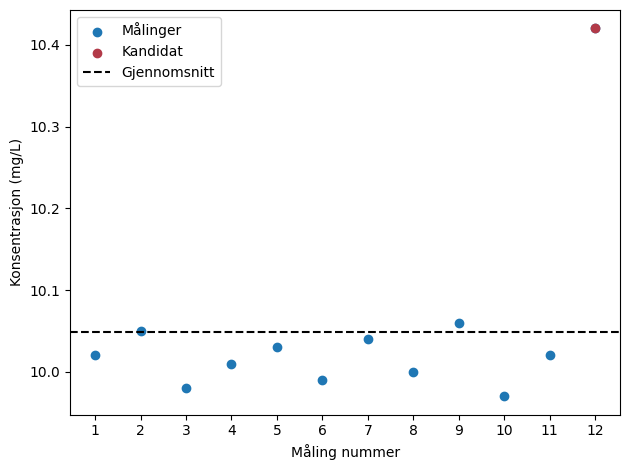

In [9]:
measurements_mg_L = np.array([
    10.02, 10.05, 9.98, 10.01, 10.03, 9.99,
    10.04, 10.00, 10.06, 9.97, 10.02, 10.42,
])
alpha = 0.05

n = len(measurements_mg_L)
mean = np.mean(measurements_mg_L)
sample_sd = np.std(measurements_mg_L, ddof=1)
deviations = np.abs(measurements_mg_L - mean)

suspect_index = np.argmax(deviations)
suspect_value = measurements_mg_L[suspect_index]
G_calculated = deviations[suspect_index] / sample_sd

# Tosidig kritisk verdi for én mulig utligger.
t_critical = stats.t.ppf(1 - alpha / (2 * n), df=n - 2)
G_critical = (n - 1) / np.sqrt(n) * np.sqrt(
    t_critical**2 / (n - 2 + t_critical**2)
)

flagged = G_calculated > G_critical

print(f"Antall målinger: {n}")
print(f"Kandidat:        {suspect_value:.2f} mg/L")
print(f"Beregnet G:      {G_calculated:.3f}")
print(f"Kritisk G:       {G_critical:.3f}")
print(f"Statistisk flagg: {flagged}")

measurement_number = np.arange(1, n + 1)
plt.scatter(measurement_number, measurements_mg_L, label="Målinger")
plt.scatter(
    measurement_number[suspect_index],
    suspect_value,
    color="#b23a48",
    label="Kandidat",
    zorder=3,
)
plt.axhline(mean, color="black", linestyle="--", label="Gjennomsnitt")
plt.xlabel("Måling nummer")
plt.ylabel("Konsentrasjon (mg/L)")
plt.xticks(measurement_number)
plt.legend()
plt.tight_layout()
plt.show()


I eksemplet blir 10,42 mg/L flagget. Konklusjonen er likevel ikke «slett 10,42», men «undersøk 10,42 og hvordan målingen ble produsert».

```{admonition} Fra statistisk flagg til faglig beslutning
:class: important

1. Kontroller rådata, enheter, prøvepreparering, instrumentlogg og laboratorienotater.
2. Vurder om observasjonen kan representere reell kjemisk variasjon.
3. Dersom en konkret feil dokumenteres, kan eksklusjon være faglig begrunnet. Rapporter både kriteriet og hva som ble utelatt.
4. Dersom årsaken er ukjent, bør observasjonen normalt beholdes. Vis gjerne en sensitivitetsanalyse med og uten kandidaten, men ikke skjul noen av resultatene.
5. Ikke slett den flaggede verdien og gjenta Grubbs' test til datasettet ser pent ut. Gjentatt testing øker risikoen for uberettigede eksklusjoner.
```

Grubbs' test forutsetter uavhengige observasjoner, en omtrent normalfordelt populasjon og én mulig utligger. Dersom flere observasjoner virker avvikende, er denne testen ikke riktig verktøy; undersøk heller forsøket og vurder robuste beskrivelser eller en modell som passer datagenereringen.

Du kan undersøke beregningen i editoren nedenfor.

<iframe src="../../basthon/?from=examples/calibration_grubbs.py" width="100%" height="700" frameborder="0" title="Interaktiv Python-editor for Grubbs' test" loading="lazy" allowfullscreen></iframe>

````{admonition} Underveisoppgave
:class: tip
Testen flagger 10,42 mg/L. Skriv tre ulike mulige forklaringer på observasjonen: én registreringsfeil, én eksperimentell feil og én reell kjemisk forklaring. Hvilken dokumentasjon trenger du før du eventuelt utelater målingen?

```{admonition} Løsningsforslag
:class: tip, dropdown
Et eksempel på registreringsfeil er feil desimalskilletegn eller enhet. En eksperimentell feil kan være dokumentert feilpipettering eller en instrumentadvarsel. En reell kjemisk forklaring kan være at prøven faktisk har en annen sammensetning. Testresultatet kan ikke skille disse forklaringene; vi trenger rådata, laboratorienotater, instrumentlogg og kunnskap om prøven. Uten dokumentert grunnlag er statistisk flagging alene ikke tilstrekkelig for sletting.
```
````


## En praktisk arbeidsflyt

Når vi bruker statistikk i et kjemisk arbeid, kan vi følge denne rekkefølgen:

1. **Formuler det kjemiske spørsmålet og identifiser forsøksenheten.** Hva representerer én observasjon?
2. **Undersøk rådataene.** Se etter manglende verdier, umulige verdier og uventede mønstre.
3. **Visualiser før du tester.** Vis enkeltmålinger og paring der det er relevant.
4. **Velg modell eller test fra forsøksdesignet.** Kalibrering, ett utvalg, uavhengige grupper eller parede målinger?
5. **Kontroller viktige forutsetninger.** Uavhengighet, fordeling og relevant modellform.
6. **Rapporter estimat og usikkerhet.** Oppgi forskjell og konfidensintervall sammen med teststatistikk, frihetsgrader og p-verdi.
7. **Tolk kjemisk.** Er størrelsen på forskjellen viktig for bruksområdet?
8. **Dokumenter all databehandling.** En leser skal kunne rekonstruere hva som ble gjort, særlig ved eventuell eksklusjon.

Python utfører beregningene, men det vitenskapelige valget og tolkningen er fortsatt vårt ansvar.


## Kort oppsummering

- Lineær regresjon kan knytte et målt signal til konsentrasjon innenfor et undersøkt kalibreringsområde.
- Stigningstall, konstantledd og $R^2$ må tolkes sammen med rådataene og den kjemiske modellen.
- En ukjent prøve bør normalt ligge innenfor det validerte kalibreringsområdet.
- P-verdien beregnes betinget på nullhypotesen og modellforutsetningene; den er ikke sannsynligheten for at nullhypotesen er sann.
- Ettutvalgs, uavhengig og paret t-test brukes for ulike forsøksdesign.
- Statistisk signifikans og kjemisk betydning er forskjellige spørsmål.
- Rapporter forskjell og konfidensintervall sammen med $t$, $df$ og $p$.
- Statistisk utliggerdeteksjon hører først og fremst hjemme ved utvalg med tosifret $n$.
- Grubbs' test kan flagge én mulig utligger, men kan aldri alene begrunne at målingen slettes.


## Oppgaver

```{admonition} Oppgave 4.1 – forstå kalibreringslinja
:class: tip
Bruk `data/uvvis_calibration.csv` til å utføre en lineær regresjon. Rapporter stigningstall, konstantledd og $R^2$. Forklar med ord hva stigningstallet og konstantleddet betyr i denne UV–Vis-analysen.
```

```{admonition} Oppgave 4.2 – rådata og gjennomsnitt
:class: tip
Lag først et plott med alle kalibreringsreplikatene. Lag deretter et plott med én middelabsorbans per konsentrasjon og standardavvik som feilstolper. Hvilken informasjon kommer tydeligst fram i hvert plott?
```

```{admonition} Oppgave 4.3 – ukjent prøve
:class: tip
Beregn middelabsorbansen til den ukjente prøven og bestem konsentrasjonen med kalibreringsmodellen. Er dette interpolasjon eller ekstrapolasjon? Forklar hvorfor forskjellen er viktig.
```

```{admonition} Oppgave 4.4 – referanseverdi
:class: tip
Målingene `[99.8, 100.3, 100.1, 99.9, 100.4]` mg/L skal sammenliknes med en sertifisert verdi på 100,0 mg/L. Beregn estimert forskjell, 95 % konfidensintervall og ettutvalgs t-test. Rapporter $t$, $df$ og $p$, og skill mellom statistisk evidens og praktisk betydning.
```

```{admonition} Oppgave 4.5 – uavhengige grupper
:class: tip
Utbyttet fra en syntese måles i uavhengige forsøk med to katalysatorer:

- Katalysator A: `[78.2, 79.1, 77.8, 80.0, 78.6]` %
- Katalysator B: `[81.3, 80.7, 82.1, 81.5, 80.9]` %

Formuler $H_0$ og $H_1$, beregn gjennomsnitt og forskjell med 95 % konfidensintervall, og utfør Welchs t-test. Hva i forsøksdesignet må være sant for at observasjonene kan regnes som uavhengige?
```

```{admonition} Oppgave 4.6 – paret eller uavhengig?
:class: tip
Avgjør om en uavhengig eller paret test passer i hvert tilfelle: to instrumenter måler de samme prøvene; to separate produksjonsbatcher undersøkes; samme prøve måles før og etter behandling. Begrunn hvert valg.
```

```{admonition} Oppgave 4.7 – to analysemetoder
:class: tip
Bruk `data/method_comparison.csv`. Beregn metode B minus metode A for hver prøve, middelverdien og 95 % konfidensintervallet for forskjellene. Utfør en paret t-test og rapporter $t$, $df$ og $p$. Er størrelsen på forskjellen viktig for bruksområdet?
```

```{admonition} Oppgave 4.8 – Grubbs' test og faglig beslutning
:class: tip
Bruk måleserien `[10.02, 10.05, 9.98, 10.01, 10.03, 9.99, 10.04, 10.00, 10.06, 9.97, 10.02, 10.42]` mg/L. Utfør Grubbs' test og skriv deretter en beslutningslogg med: observert problem, statistisk resultat, mulige kjemiske og eksperimentelle forklaringer, nødvendig dokumentasjon og hvordan resultatet skal rapporteres.
```

```{admonition} Oppgave 4.9 – hvorfor ikke teste fem replikater?
:class: tip
En student vil bruke Grubbs' test på fem replikater og slette den høyeste verdien dersom den flagges. Forklar minst tre problemer med framgangsmåten og foreslå en bedre arbeidsflyt.
```

```{admonition} Oppgave 4.10 – samlet UV–Vis-case
:class: tip
Bruk `data/uvvis_calibration.csv` til å lage et kalibreringsplott, utføre lineær regresjon og bestemme konsentrasjonen til den ukjente prøven. Skriv en kort rapport som inneholder modell, enheter, konsentrasjonsestimat og minst to begrensninger ved resultatet.
```


## Video

I videoen nedenfor kan du få en innføring eller repetisjon i regresjonsanalyse.

<iframe width="800" height="600" src="https://www.youtube.com/embed/GrLWboUtL3A?autoplay=0&rel=0" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
